Multi Agent RAG

- multi agent network

api keys and LLM setup

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025D6D34B380>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025D701249B0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Building the individual agents
- researcher agent
- blog writer agent

In [5]:
#libraries
from typing import Annotated,Literal
from langchain_tavily import TavilySearch
from langchain_core.tools import tool,Tool
from langchain_community.utilities.wikidata import WikidataAPIWrapper
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

C:\Users\Dell\AppData\Local\Temp\ipykernel_1156\2315101976.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities.wikidata import WikidataAPIWrapper


building the tools

In [6]:
tavily_tool = TavilySearch(max_results=5)
tavily_tool

TavilySearch(max_results=5, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

In [7]:
def make_retriever_tool_from_text(file,name,desc):
    docs = TextLoader(file,encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(docs)
    vs = FAISS.from_documents(chunks,HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2"))
    retriever = vs.as_retriever()
    
    def tool_func(query: str) -> str:
        result = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in result)
    
    return Tool(name=name,description=desc,func=tool_func)

internal_tool_1 = make_retriever_tool_from_text("research_notes.txt","ResearchNotesTool","Search research notes for projects and other information")
internal_tool_1

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Tool(name='ResearchNotesTool', description='Search research notes for projects and other information', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x0000025D024DB6A0>)

In [8]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import MessagesState,END
from langchain.agents import create_agent
from langgraph.types import Command

def get_nextnode(last_message: BaseMessage,goto: str):
    content = last_message.content
    if isinstance(content,str) and 'FINAL ANSWER' in last_message.content:
        return END
    return goto

In [9]:
def make_system_prompt(suffix: str) -> str:
    return (
        f"""You are a helpful AI assistant, collaborating with other assitants.
        Use the provided tools to progress towards answering the question
        If you are unable to fully answer, thats OK, another assitant with different tools
        will help where you left off. Execute what you can to make progress.
        If you or any of the other assitants have the final answer or deliverbale,
        prefix your response with FINAL ANSWER so the team knows to stop.
        \n{suffix}"""
    )

Building the Research Agent and Node

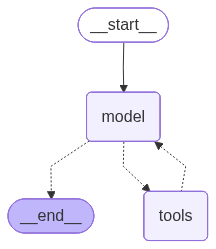

In [10]:
research_agent = create_agent(
    llm,
    tools=[internal_tool_1,tavily_tool],
)
research_agent

In [11]:
def research_node(state: MessagesState) -> Command[Literal["blog_generator",END]]:
    result = research_agent.invoke({
        "messages":[
            {
                "role":"system",
                "content":make_system_prompt("You can only do research. You are working with a content writer colleague."),
            },
            *state['messages'],
        ]
    })
    goto = get_nextnode(result["messages"][-1],"blog_generator")
    # not all providers allow ai msg since wrapping it in human message
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="researcher"
    )
    return Command(
        update={
            "messages":result["messages"]
        },
        goto=goto
    )

Building the Blog Writer Agent and Node

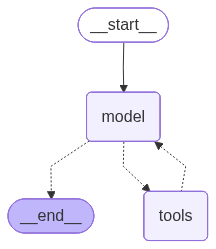

In [12]:
blog_agent = create_agent(
    llm,
    tools=[tavily_tool]
)
blog_agent

In [13]:
def blog_node(state: MessagesState) -> Command[Literal["researcher",END]]:
    result = blog_agent.invoke({
        "messages":[
            {
                "role":"system",
                "content":make_system_prompt("You can only write a detailed blog. You are working with a researcher colleague."),
            },
            *state['messages']
        ]
    })
    goto = get_nextnode(result["messages"][-1],"researcher")
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="blog_generator"
    )
    return Command(
        update={
            "messages":result["messages"]
        },
        goto=goto
    )

building the graph

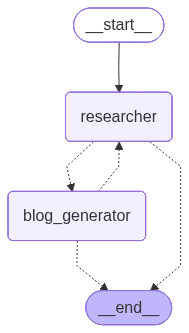

In [14]:
from langgraph.graph import StateGraph,START
workflow = StateGraph(MessagesState)
workflow.add_node("researcher",research_node)
workflow.add_node("blog_generator",blog_node)
workflow.add_edge(START,"researcher")
graph = workflow.compile()
graph

testing the system

In [ ]:
response = graph.invoke(
    {
        "messages": [
            {"role": "user", "content": "Write a detailed blog on project Falcon, Nova and Atlas"}
        ]
    },
    config={"recursion_limit": 25}
)
response

Supervisor Multi Agent RAG

renaming tavily tool

In [15]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(max_results=3)
web_search

TavilySearch(max_results=3, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

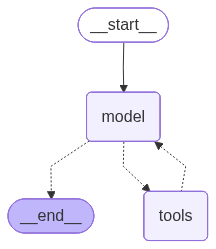

In [22]:
research_agent =  create_agent(
    model=llm,
    tools=[web_search,internal_tool_1],
system_prompt = """You are a research agent.
INSTRUCTIONS:\n
- assist only with research-related tasks, do not do any math\n
- after youre done with your tasks,respond to the supervisor directly\n
- respond only with the results of your work, do not include any other text.""",
name="research_agent"
)
research_agent

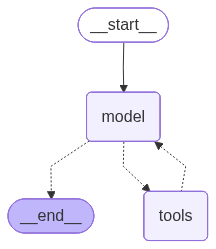

In [26]:
def add(a: float, b: float):
    """Add two numbers"""
    return a+b


def multiply(a: float, b: float):
    """Multiply two numbers"""
    return a*b


def divide(a: float, b: float):
    """Divide two numbers"""
    return a / b


math_agent = create_agent(
    model=llm,
    tools=[add, multiply, divide],
    system_prompt="""You are a math agent.
INSTRUCTIONS:\n
- assist only with math related tasks, do not do any research\n
- after youre done with your tasks,respond to the supervisor directly\n
- respond only with the results of your work, do not include any other text.""",
name="math_agent"
)
math_agent

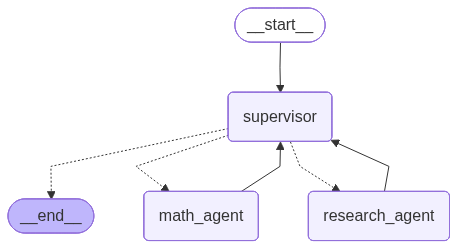

In [27]:
from langgraph_supervisor import create_supervisor

supervisor = create_supervisor(
    model=llm,
    agents=[research_agent,math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n" \
        "- a math agent. Assign math-related tasks to this agent.\n" \
        "Assign work to one agent at a time, do not call agents in parallel." \
        "Do not do any work yourself"
    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
).compile()
supervisor

In [28]:
response = supervisor.invoke({"messages":"List all the projects and their data from the retriever and tell me what is 5 plus 10"})

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: attempted to call tool 'transfer_to_supervisor' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=transfer_to_supervisor>{}</function>'}}